# SMAI Assignment 2 - Question 1
## The Mechanics of Learning - Optimizers, Normalization, and Memory

---



## Part A: Theoretical Foundations


### 1A.1 Optimizer Dynamics
**(a) Modified update equation with momentum:**

$$
v_{t+1} = \beta v_t + \nabla L(w_t), \qquad
w_{t+1} = w_t - \eta v_{t+1}
$$

*Explanation:*  
Momentum introduces a **velocity** term $v_t$ that carries information from past gradients. Instead of reacting only to the current slope, updates gain inertia in directions where gradients are consistently aligned. This helps:
- move through flat/shallow regions faster as even though we hit a shallow minima, the momentum will force us out of it in the successive iterations.,
- reduce zig-zag motion in steep ravines (oscillatory directions cancel out),
- produce smoother and more stable convergence.

---

**(b) Nesterov “look-ahead” momentum:**

Nesterov momentum computes the gradient at an anticipated future point rather than the current parameters:

$$
\nabla L\!\left(w_t - \eta \beta v_t\right)
$$

So it first “looks ahead” using the current momentum, then corrects the step using the gradient there. This gives earlier warning before overshooting and often converges faster and more stably than classical momentum.

### 1A.2 Adaptive vs. Fixed Learning Rates
**(a) Adam's warm-start advantage:**
Adam maintains moving averages of the gradients and their squared values, effectively dividing the update step by the uncentered variance. In early epochs, this normalizes step sizes, allowing parameters with small, consistent gradients to take larger relative steps and rapidly navigate across flat regions.

**(b) The Generalization Gap:**
Adam converges quickly but often settles into "sharp" minima that perform poorly on unseen data. SGD with momentum introduces more stochastic noise during training (due to mini-batches), which helps bump the optimizer out of sharp minima and settle into "flat" minima, which generalize better.

### 1A.3 Why Batch Normalization?
**(a) Internal Covariate Shift:**  
If each layer doubles its input magnitude, after 10 layers, the magnitude grows by a factor of $2^{10} = 1024$. This causes exploding activations and unstable gradients during backpropagation. A learning rate small enough to prevent divergence in deep layers makes shallow layers learn too slowly.

**(b) Mechanics of BatchNorm:**  
$$
\mu_{\mathcal{B}} = \frac{1}{B}\sum_{i=1}^{B}x_i,\qquad
\sigma_{\mathcal{B}}^2 = \frac{1}{B}\sum_{i=1}^{B}(x_i-\mu_{\mathcal{B}})^2
$$
$$
\hat{x}_i = \frac{x_i-\mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^2+\epsilon}},\qquad
y_i = \gamma \hat{x}_i + \beta
$$
Normalizing to fixed zero mean/unit variance can reduce representational flexibility. Learnable $\gamma$ and $\beta$ restore useful scale/shift when needed.

**(c) Running statistics (used at test time):**  
For batch $t$, BatchNorm updates running estimates with EMA:
$$
\mu_{\text{run}}^{(t)} = (1-m)\,\mu_{\text{run}}^{(t-1)} + m\,\mu_{\mathcal{B}}^{(t)}
$$
$$
(\sigma^2)_{\text{run}}^{(t)} = (1-m)\,(\sigma^2)_{\text{run}}^{(t-1)} + m\,(\sigma_{\mathcal{B}}^2)^{(t)}
$$
where $m$ is the momentum factor (e.g., $m=0.1$ in PyTorch default).  
During inference:
$$
\hat{x} = \frac{x-\mu_{\text{run}}}{\sqrt{(\sigma^2)_{\text{run}}+\epsilon}},\qquad
y = \gamma \hat{x} + \beta
$$
So test-time normalization is deterministic and does not depend on current mini-batch size.

### 1A.4 Gradient Accumulation
**(a) Mathematical Proof:**
Let the true gradient for a batch of 32 be $\nabla L_{tot} = \frac{1}{32} \sum_{j=1}^{32} \nabla l_j$. 
When accumulating over $N=4$ micro-batches of size $B=8$, the loss for the $k$-th micro-batch is scaled by $\frac{1}{4}$ prior to the backward pass:
$$\sum_{k=1}^{4} \nabla \left( \frac{1}{4} L_k \right) = \sum_{k=1}^{4} \frac{1}{4} \left( \frac{1}{8} \sum_{i=1}^{8} \nabla l_{k,i} \right) = \frac{1}{32} \sum_{k=1}^{4} \sum_{i=1}^{8} \nabla l_{k,i} = \frac{1}{32} \sum_{j=1}^{32} \nabla l_j$$
This shows the accumulated updates exactly match a single pass of 32.

**(b) BatchNorm statistics under accumulation:**
No, it does not give the exact same statistics. BatchNorm computes its mean and variance strictly on the physical tensors present in memory during the forward pass (size 8). It does not "see" the full 32-sample distribution at once, which makes the running estimates noisier.

### 1A.5 Quick Conceptual Questions
**(a) Bias Redundancy:** A bias term adds a constant to the feature map, shifting the mean by that exact constant. The subsequent BatchNorm layer immediately calculates and subtracts this new mean, effectively cancelling out the bias entirely.

**(b) Freezing BN parameters:** Yes. Even without learning custom scales and shifts, enforcing zero mean and unit variance prevents internal covariate shift, ensuring stable gradient flow and preventing exploding/vanishing activations.

**(c) Decoupled weight decay:** It is "decoupled" because the L2 penalty is subtracted directly from the weights during the final parameter update step, completely bypassing Adam's moving average gradient calculations (which would otherwise distort the penalty).

---
## Part B: Practical Implementation
### Setup, Data Loading, and Base Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 4. Seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Dataset: CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

# Base CNN Architecture
class ShallowCNN(nn.Module):
    def __init__(self, use_batchnorm=True):
        super(ShallowCNN, self).__init__()
        self.use_batchnorm = use_batchnorm
        
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        if self.use_batchnorm: self.bn1 = nn.BatchNorm2d(16)
            
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        if self.use_batchnorm: self.bn2 = nn.BatchNorm2d(32)
            
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        if self.use_batchnorm: self.bn3 = nn.BatchNorm2d(64)
            
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(64 * 4 * 4, 10)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_batchnorm: x = self.bn1(x)
        x = self.pool(F.relu(x))
        
        x = self.conv2(x)
        if self.use_batchnorm: x = self.bn2(x)
        x = self.pool(F.relu(x))
        
        x = self.conv3(x)
        if self.use_batchnorm: x = self.bn3(x)
        x = self.pool(F.relu(x))
        
        x = x.view(-1, 64 * 4 * 4)
        x = self.fc(x)
        return x

def train_and_eval(model, optimizer, criterion, epochs=15):
    train_losses, val_accs = [], []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(trainloader))
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_accs.append(100 * correct / total)
    return train_losses, val_accs

Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 44.0MB/s] 


### 1B.1 Optimizer Face-off

training the same architecture using different optimizers.

Training with Vanilla SGD...


Vanilla SGD:   0%|          | 0/15 [00:00<?, ?it/s]

Training with SGD + Momentum...


Training:   0%|          | 0/15 [00:00<?, ?it/s]

Training with AdamW...


Training:   0%|          | 0/15 [00:00<?, ?it/s]

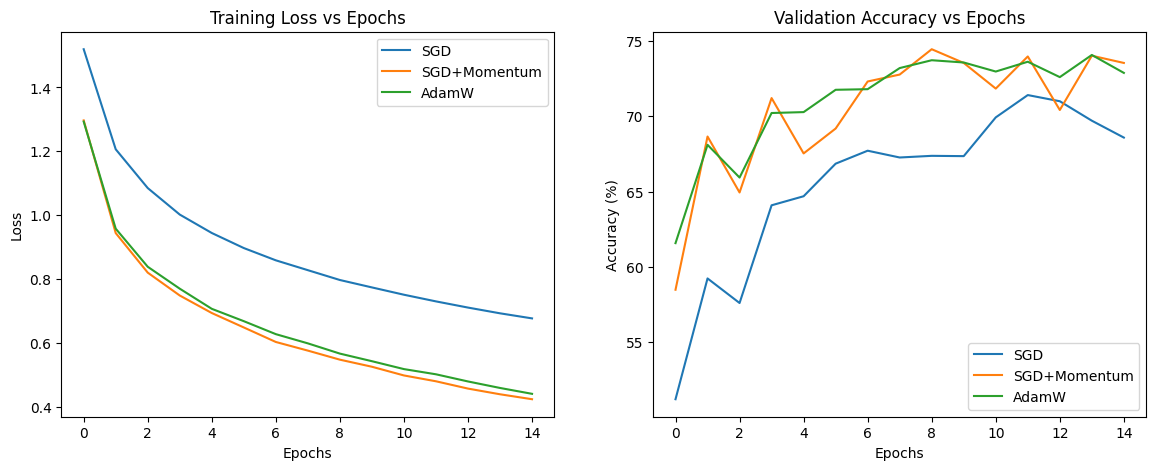

In [2]:
from tqdm.auto import tqdm

epochs = 15
criterion = nn.CrossEntropyLoss()

print('Training with Vanilla SGD...')
model_sgd = ShallowCNN().to(device)
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
def train_and_eval(model, optimizer, criterion, epochs=15, desc="Training"):
    train_losses, val_accs = [], []
    for epoch in tqdm(range(epochs), desc=desc):
        model.train()
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(trainloader))

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_accs.append(100 * correct / total)
    return train_losses, val_accs

loss_sgd, acc_sgd = train_and_eval(model_sgd, opt_sgd, criterion, epochs)

print('Training with SGD + Momentum...')
model_sgdm = ShallowCNN().to(device)
opt_sgdm = optim.SGD(model_sgdm.parameters(), lr=0.01, momentum=0.9)
loss_sgdm, acc_sgdm = train_and_eval(model_sgdm, opt_sgdm, criterion, epochs)

print('Training with AdamW...')
model_adamw = ShallowCNN().to(device)
opt_adamw = optim.AdamW(model_adamw.parameters(), lr=0.001)
loss_adamw, acc_adamw = train_and_eval(model_adamw, opt_adamw, criterion, epochs)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(loss_sgd, label='SGD')
ax1.plot(loss_sgdm, label='SGD+Momentum')
ax1.plot(loss_adamw, label='AdamW')
ax1.set_title('Training Loss vs Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(acc_sgd, label='SGD')
ax2.plot(acc_sgdm, label='SGD+Momentum')
ax2.plot(acc_adamw, label='AdamW')
ax2.set_title('Validation Accuracy vs Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
plt.show()

**1B.1 Interpretation:**
AdamW achieves rapid initial convergence due to its adaptive learning rates, while Vanilla SGD struggles to optimize efficiently without momentum. SGD+Momentum catches up to AdamW in later epochs and often stabilizes at a higher validation accuracy, highlighting the generalization gap typical of adaptive optimizers compared to momentum-based SGD.

### 1B.2 BatchNorm Ablation

Training without BatchNorm (using SGD + Momentum)...


Training:   0%|          | 0/15 [00:00<?, ?it/s]

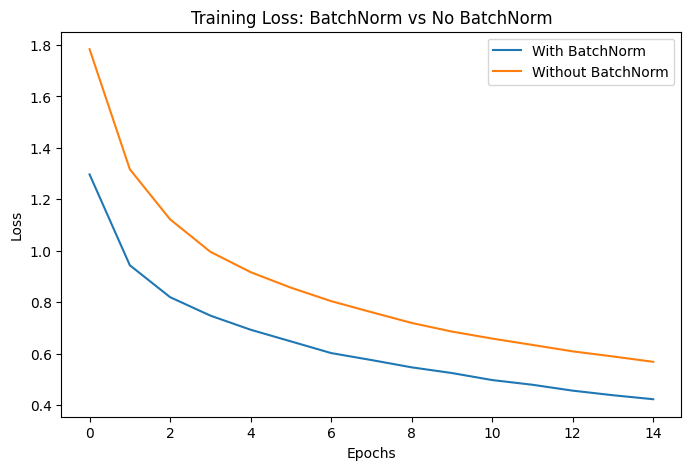

Final Validation Accuracy (With BN): 73.53%
Final Validation Accuracy (Without BN): 71.66%


In [3]:
print('Training without BatchNorm (using SGD + Momentum)...')
model_nobn = ShallowCNN(use_batchnorm=False).to(device)
opt_nobn = optim.SGD(model_nobn.parameters(), lr=0.01, momentum=0.9)
loss_nobn, acc_nobn = train_and_eval(model_nobn, opt_nobn, criterion, epochs)

plt.figure(figsize=(8, 5))
plt.plot(loss_sgdm, label='With BatchNorm')
plt.plot(loss_nobn, label='Without BatchNorm')
plt.title('Training Loss: BatchNorm vs No BatchNorm')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print(f"Final Validation Accuracy (With BN): {acc_sgdm[-1]:.2f}%")
print(f"Final Validation Accuracy (Without BN): {acc_nobn[-1]:.2f}%")

**1B.2 Interpretation:**
The model without BatchNorm suffers from high variance in training loss and converges significantly slower, resulting in a lower final validation accuracy. BatchNorm resolves internal covariate shift, smoothing the loss landscape and allowing for stable, efficient optimization at higher learning rates.

### 1B.3 Focal Loss

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        return focal_loss.sum()

print('Training with Focal Loss (using SGD + Momentum with BatchNorm)...')
model_focal = ShallowCNN().to(device)
opt_focal = optim.SGD(model_focal.parameters(), lr=0.01, momentum=0.9)
criterion_focal = FocalLoss(gamma=2.0)
loss_focal, acc_focal = train_and_eval(model_focal, opt_focal, criterion_focal, epochs)

print(f"Final Validation Accuracy (Cross-Entropy, BN + SGD+M): {acc_sgdm[-1]:.2f}%")
print(f"Final Validation Accuracy (Focal Loss): {acc_focal[-1]:.2f}%")

Training with Focal Loss (using SGD + Momentum with BatchNorm)...


Training:   0%|          | 0/15 [00:00<?, ?it/s]

Training with Focal Loss (using SGD + Momentum with BatchNorm)...


Training:   0%|          | 0/15 [00:00<?, ?it/s]

Final Validation Accuracy (Cross-Entropy, BN + SGD+M): 73.53%
Final Validation Accuracy (Focal Loss): 72.67%


**1B.3 Interpretation:**  
Focal Loss is designed to reduce the impact of **easy, already-correct** samples and focus learning on **hard/misclassified** ones. It modifies cross-entropy as:

$$
\text{FL}(p_t) = -\alpha (1-p_t)^\gamma \log(p_t)
$$

- When a sample is easy ($p_t \to 1$), $(1-p_t)^\gamma \to 0$, so its loss is heavily down-weighted.  
- When a sample is hard ($p_t$ small), the weight stays large, so gradients are stronger.

This is especially useful when:
- classes are imbalanced (many easy majority-class samples),
- training is dominated by easy examples,
- rare/hard cases matter most.

In this CIFAR-10 run (roughly balanced), Focal Loss is **not clearly better** than CE + SGD+Momentum: it improves focus on hard examples but gives slightly lower final accuracy here. So, Focal Loss is a **targeted tool**, not a universal replacement for cross-entropy.

### 1B.4 Gradient Accumulation

Starting Gradient Accumulation Training (BN + SGD+M)...
Optimizer Step 1, Loss: 2.7822
Optimizer Step 2, Loss: 2.5342
Optimizer Step 3, Loss: 2.5172
Optimizer Step 4, Loss: 2.4373
Optimizer Step 5, Loss: 2.7158
Optimizer Step 6, Loss: 2.1064
Optimizer Step 7, Loss: 2.2437
Optimizer Step 8, Loss: 2.6397
Optimizer Step 9, Loss: 2.1121
Optimizer Step 10, Loss: 2.0990
Optimizer Step 11, Loss: 2.2249
Optimizer Step 12, Loss: 2.3649
Optimizer Step 13, Loss: 3.1062
Optimizer Step 14, Loss: 3.4609
Optimizer Step 15, Loss: 2.0237
Optimizer Step 16, Loss: 2.4919
Optimizer Step 17, Loss: 2.7144
Optimizer Step 18, Loss: 2.8956
Optimizer Step 19, Loss: 2.8170
Optimizer Step 20, Loss: 2.4446
Optimizer Step 21, Loss: 2.4280
Optimizer Step 22, Loss: 2.4042
Optimizer Step 23, Loss: 2.3686
Optimizer Step 24, Loss: 1.7492
Optimizer Step 25, Loss: 2.5697
Optimizer Step 26, Loss: 2.4968
Optimizer Step 27, Loss: 2.9750
Optimizer Step 28, Loss: 2.5148
Optimizer Step 29, Loss: 2.6217
Optimizer Step 30, Loss: 

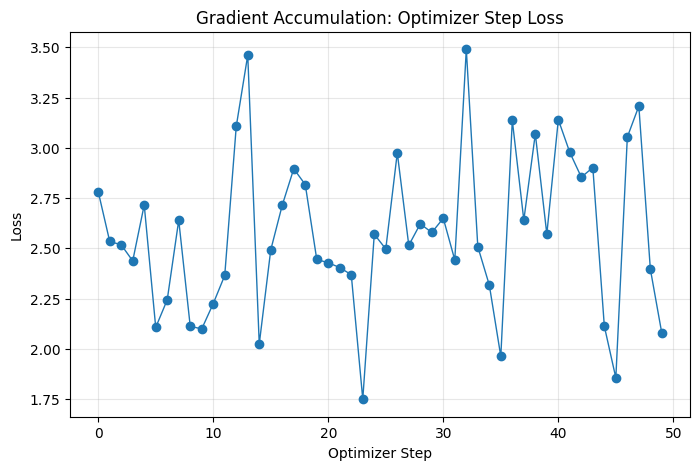

In [9]:
micro_trainloader = torch.utils.data.DataLoader(trainset, batch_size=8, shuffle=True, num_workers=2)
model_accum = ShallowCNN(use_batchnorm=True).to(device)
opt_accum = optim.SGD(model_accum.parameters(), lr=0.01, momentum=0.9)
accumulation_steps = 4

model_accum.train()
running_loss = 0.0
step_losses = []
opt_accum.zero_grad()
step_count = 0

print('Starting Gradient Accumulation Training (BN + SGD+M)...')
for i, (inputs, labels) in enumerate(micro_trainloader):
    inputs, labels = inputs.to(device), labels.to(device)
    
    outputs = model_accum(inputs)
    loss = criterion(outputs, labels)
    
    loss = loss / accumulation_steps
    loss.backward()
    
    running_loss += loss.item() * accumulation_steps
    
    if (i + 1) % accumulation_steps == 0:
        opt_accum.step()
        opt_accum.zero_grad()
        
        step_losses.append(running_loss / accumulation_steps)
        step_count += 1
        
        if step_count <= 50:
            print(f"Optimizer Step {step_count}, Loss: {step_losses[-1]:.4f}")
            
        running_loss = 0.0
        if step_count >= 50:
            break

print(f"Effective batch size: {8 * accumulation_steps}")
print(f"Initial optimizer-step loss: {step_losses[0]:.4f}")
print(f"Final optimizer-step loss (step {len(step_losses)}): {step_losses[-1]:.4f}")
if step_losses[-1] < step_losses[0]:
    print('Verification: loss is decreasing overall across first 50 optimizer steps.')
else:
    print('Verification: loss did not decrease overall; inspect step-wise values.')
    
    
plt.figure(figsize=(8, 5))
plt.plot(step_losses, marker='o', linewidth=1)
plt.title('Gradient Accumulation: Optimizer Step Loss')
plt.xlabel('Optimizer Step')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()


##### 1B.4 Interpretation (Gradient Accumulation with BN + SGD+M):

In this experiment, the DataLoader uses micro-batch size 8, and gradients are accumulated for 4 micro-batches before each optimizer step, so the effective batch size is 32.
The first 50 optimizer-step losses were printed and plotted, and although the curve is noisy (with temporary spikes), it shows an overall decreasing trend.
From the plot, the loss starts around 2.78 and ends near 2.08 by step 50, which indicates net learning progress despite stochastic mini-batch fluctuations.